# Valence and Dominance of GoEmotions Labels

This notebook visualizes the affective positions of each emotion label using the BRM/ANEW-derived VAD table.

The main plot places **valence** on the x-axis and **dominance** on the y-axis, so each emotion label becomes one point in affective space. A second grouped bar chart shows the raw valence and dominance values label by label.

Interpretation reminders, because plots love to pretend they are truth machines:

- **Valence**: how positive vs. negative the emotion is.
- **Dominance**: how controlled/powerful vs. submissive/overwhelmed the emotion feels.
- These are label-level approximations, not direct measurements of every comment.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 220
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Change this path if your CSV lives somewhere else.
# The notebook first tries the current working directory, then /mnt/data for ChatGPT runs,
# then a common Windows project path.
possible_paths = [
    Path("emotion_label_vad_from_BRM.csv"),
    Path("/mnt/data/emotion_label_vad_from_BRM.csv"),
    Path("D:/pyprojects/m4r/emotion_label_vad_from_BRM.csv"),
    Path("D:/pyprojects/m4r/data/goemotions/emotion_label_vad_from_BRM.csv"),
]

DATA_PATH = next((p for p in possible_paths if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find emotion_label_vad_from_BRM.csv. "
        "Put it next to this notebook or update DATA_PATH manually."
    )

OUT_DIR = Path("valence_dominance_outputs")
OUT_DIR.mkdir(exist_ok=True)

print(f"Using VAD file: {DATA_PATH.resolve()}")
print(f"Saving plots to: {OUT_DIR.resolve()}")

Using VAD file: /mnt/data/emotion_label_vad_from_BRM.csv
Saving plots to: /mnt/data/valence_dominance_outputs


In [2]:
vad = pd.read_csv(DATA_PATH)

required = {"label_name", "valence", "dominance"}
missing = required - set(vad.columns)
if missing:
    raise ValueError(f"Missing required columns: {sorted(missing)}")

vad = vad.copy()
vad["label_name"] = vad["label_name"].astype(str)
vad["valence"] = pd.to_numeric(vad["valence"], errors="coerce")
vad["dominance"] = pd.to_numeric(vad["dominance"], errors="coerce")

if vad[["valence", "dominance"]].isna().any().any():
    bad = vad[vad[["valence", "dominance"]].isna().any(axis=1)]
    raise ValueError("Some labels have missing/non-numeric valence or dominance values:\n" + bad.to_string(index=False))

# Sort for easier reading in tables and bar plots.
vad_sorted = vad.sort_values(["valence", "dominance"], ascending=[True, True]).reset_index(drop=True)

print(f"Loaded {len(vad_sorted)} emotion labels.")
display(vad_sorted[["label_name", "valence", "dominance"]])

Loaded 28 emotion labels.


,label_name,valence,dominance
0,grief,2.33,3.26
1,sadness,2.40,3.84
2,anger,2.50,5.14
3,embarrassment,2.72,2.92
4,disappointment,2.79,4.08
5,fear,2.93,3.32
6,annoyance,2.95,3.45
7,nervousness,3.10,3.93
8,confusion,3.32,3.08
9,disgust,3.32,4.84


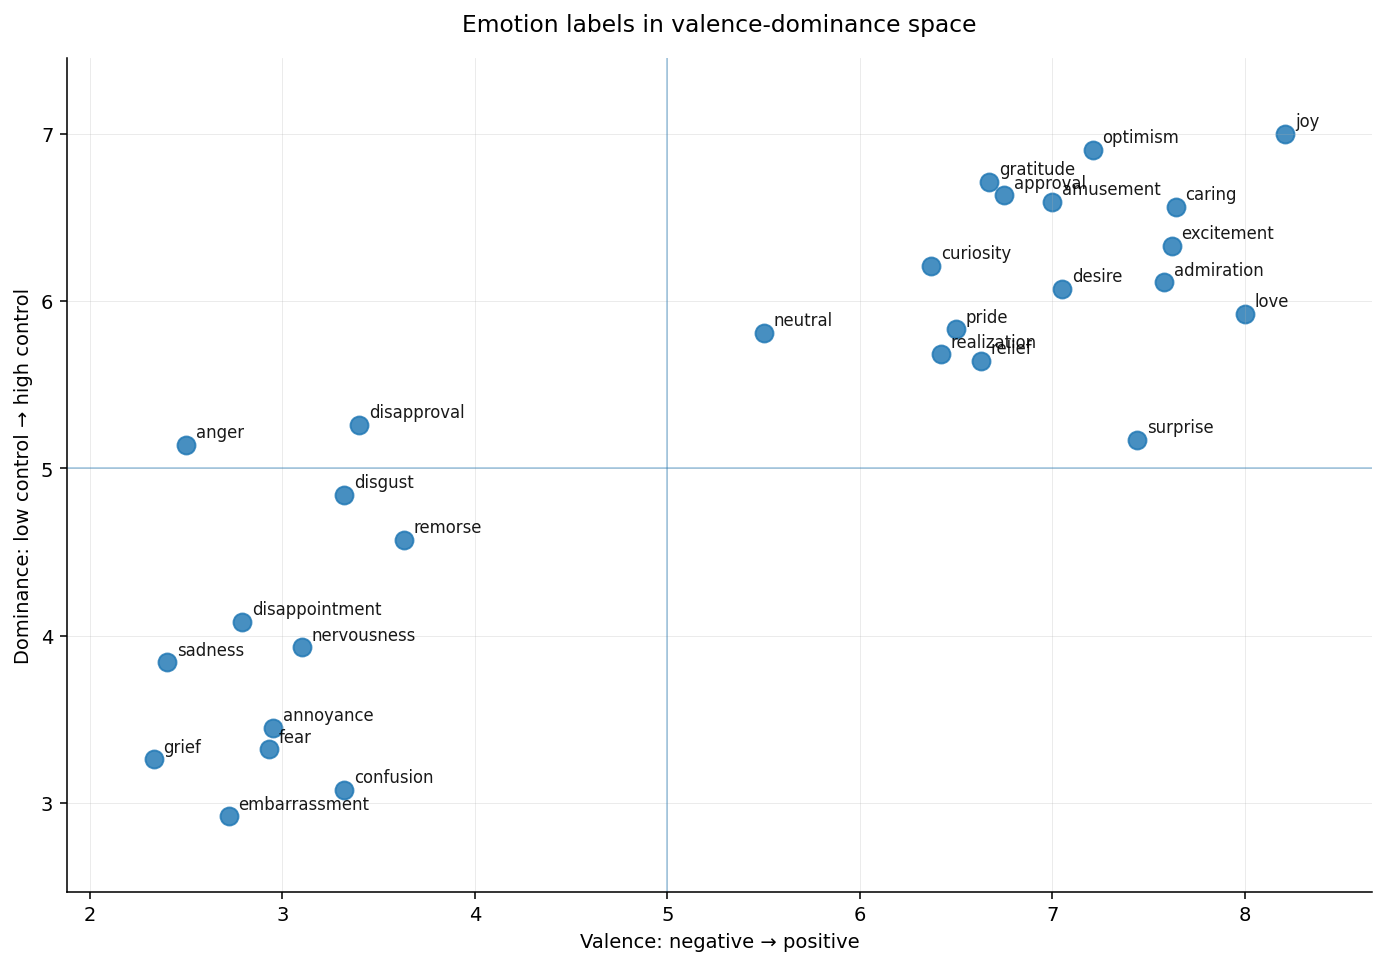

Saved: valence_dominance_outputs/emotion_valence_dominance_scatter.png


In [3]:
# Scatter plot: each emotion label in valence-dominance space.
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    vad["valence"],
    vad["dominance"],
    s=85,
    alpha=0.82,
)

# Add quadrant/reference lines at the midpoint of the 1-9 affective rating scale.
ax.axvline(5, linewidth=1, alpha=0.35)
ax.axhline(5, linewidth=1, alpha=0.35)

for _, row in vad.iterrows():
    ax.annotate(
        row["label_name"],
        xy=(row["valence"], row["dominance"]),
        xytext=(5, 4),
        textcoords="offset points",
        fontsize=8.5,
        alpha=0.9,
    )

ax.set_title("Emotion labels in valence-dominance space", pad=14)
ax.set_xlabel("Valence: negative → positive")
ax.set_ylabel("Dominance: low control → high control")
ax.set_xlim(max(1, vad["valence"].min() - 0.45), min(9, vad["valence"].max() + 0.45))
ax.set_ylim(max(1, vad["dominance"].min() - 0.45), min(9, vad["dominance"].max() + 0.45))
ax.grid(True, linewidth=0.45, alpha=0.28)

fig.tight_layout()
scatter_path = OUT_DIR / "emotion_valence_dominance_scatter.png"
fig.savefig(scatter_path, bbox_inches="tight")
plt.show()
print(f"Saved: {scatter_path}")

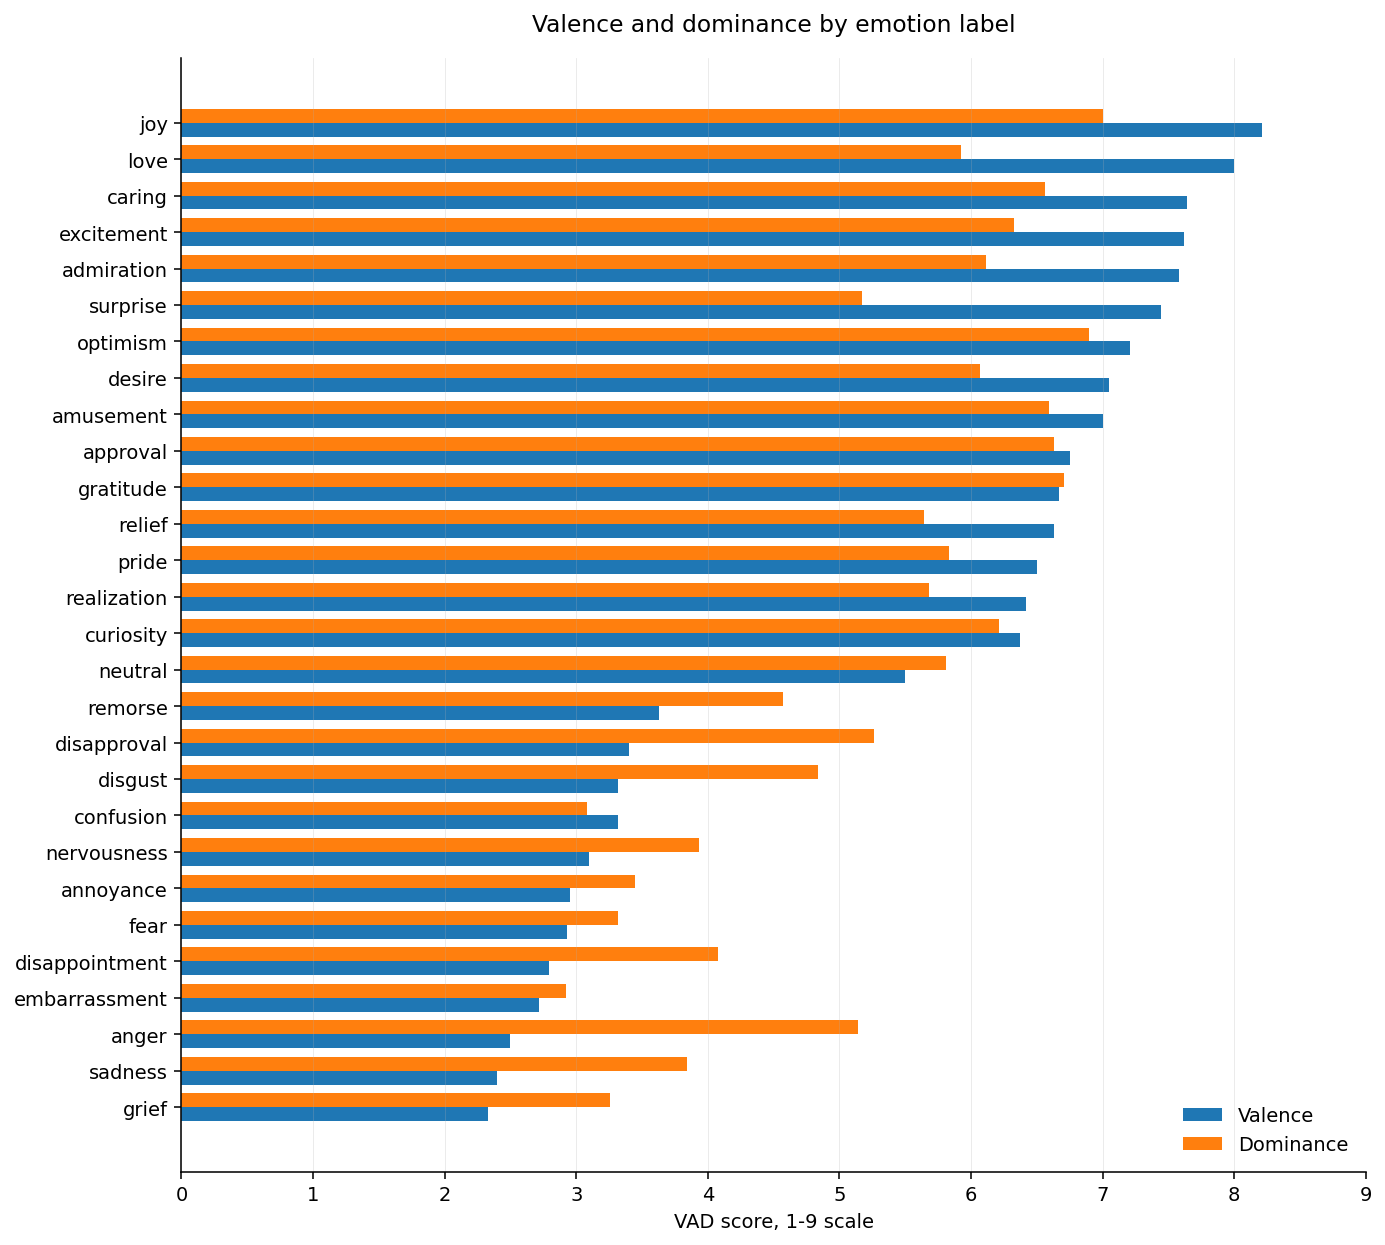

Saved: valence_dominance_outputs/emotion_valence_dominance_bars.png


In [4]:
# Grouped horizontal bar chart sorted by valence.
plot_df = vad_sorted.copy()
y = np.arange(len(plot_df))
bar_h = 0.38

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(y - bar_h / 2, plot_df["valence"], height=bar_h, label="Valence")
ax.barh(y + bar_h / 2, plot_df["dominance"], height=bar_h, label="Dominance")

ax.set_yticks(y)
ax.set_yticklabels(plot_df["label_name"])
ax.set_xlabel("VAD score, 1-9 scale")
ax.set_title("Valence and dominance by emotion label", pad=14)
ax.set_xlim(0, 9)
ax.grid(axis="x", linewidth=0.45, alpha=0.28)
ax.legend(frameon=False, loc="lower right")

fig.tight_layout()
bar_path = OUT_DIR / "emotion_valence_dominance_bars.png"
fig.savefig(bar_path, bbox_inches="tight")
plt.show()
print(f"Saved: {bar_path}")

In [5]:
# Quick numerical summary.
corr = vad["valence"].corr(vad["dominance"], method="pearson")
spearman = vad["valence"].corr(vad["dominance"], method="spearman")

summary = pd.DataFrame({
    "quantity": [
        "Pearson correlation between valence and dominance",
        "Spearman correlation between valence and dominance",
        "Lowest-valence label",
        "Highest-valence label",
        "Lowest-dominance label",
        "Highest-dominance label",
    ],
    "value": [
        round(corr, 3),
        round(spearman, 3),
        vad.loc[vad["valence"].idxmin(), "label_name"],
        vad.loc[vad["valence"].idxmax(), "label_name"],
        vad.loc[vad["dominance"].idxmin(), "label_name"],
        vad.loc[vad["dominance"].idxmax(), "label_name"],
    ]
})

display(summary)

,quantity,value
0,Pearson correlation between valence and dominance,0.872
1,Spearman correlation between valence and domin...,0.828
2,Lowest-valence label,grief
3,Highest-valence label,joy
4,Lowest-dominance label,embarrassment
5,Highest-dominance label,joy


## What to look for

Labels in the **upper-right** are both positive and high-dominance, meaning they are pleasant and relatively controlled. Labels in the **lower-left** are negative and low-dominance, meaning unpleasant and more helpless/overwhelmed.

A useful sanity check is whether emotions such as `joy`, `love`, `admiration`, and `approval` appear on the high-valence side, while `sadness`, `grief`, `anger`, and `disappointment` appear on the low-valence side. If that structure appears, the VAD table is doing something plausible instead of just decorating numbers with feelings, humanity's favorite hobby.
